# XRF55 CSI-F Doppler Sanity Check

This notebook mirrors the SHARP reproduction notebook, but uses XRF55 raw Wi-Fi CSI. It precomputes CSI-F-like Doppler traces, loads them as whole-trial samples, and trains the same SHARP-style CNN backbone as a simple activity-recognition sanity check.

Default scope is intentionally small: `Scene_1`, receiver `lb`, five subjects, six actions, and two repetitions. Increase the filters after the pipeline is known to work.

In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

RAW_ROOT = PROJECT_ROOT / "data" / "XRF55_rawdata" / "WiFi"
CACHE_ROOT = PROJECT_ROOT / "data" / "XRF55_doppler" / "csif"

SCENES = {"Scene_1"}
RECEIVERS = {"lb", "lf", "rb"}
SUBJECTS = {f"{i:02d}" for i in range(1, 30)}
ACTIONS = {"23", "33", "34", "35", "36", "39"}
TRAIN_REPETITIONS = {f"{i:02d}" for i in range(1, 16)}
VAL_REPETITIONS = {f"{i:02d}" for i in range(16, 21)}
ALL_REPETITIONS = TRAIN_REPETITIONS | VAL_REPETITIONS

print(RAW_ROOT)
print(CACHE_ROOT)

C:\Users\gianm\Development\wifi-doppler-har\data\XRF55_rawdata\WiFi
C:\Users\gianm\Development\wifi-doppler-har\data\XRF55_doppler\csif


# Cache CSI-F Doppler Traces

Each XRF55 raw file is already one action trial, so we cache one Doppler image per trial. We do not mask central Doppler bins.

In [10]:
from collections import Counter

from xrf55_dataset import cache_xrf55_csif_doppler, scan_xrf55_raw_wifi
from xrf55_doppler import ACTION_NAMES

raw_recordings = scan_xrf55_raw_wifi(RAW_ROOT)
selected_recordings = [
    recording
    for recording in raw_recordings
    if recording.scene in SCENES
    and recording.receiver in RECEIVERS
    and recording.subject in SUBJECTS
    and recording.action in ACTIONS
    and recording.repetition in ALL_REPETITIONS
]

print(f"selected raw recordings: {len(selected_recordings)}")
print(Counter(recording.action for recording in selected_recordings))

cached_recordings = cache_xrf55_csif_doppler(
    selected_recordings,
    cache_root=CACHE_ROOT,
    overwrite=False,
    mode="amplitude",
    stream_idx=None,
    rx_pair=(0, 1),
)

print(f"cached recordings: {len(cached_recordings)}")

selected raw recordings: 10440
Counter({'23': 1740, '33': 1740, '34': 1740, '35': 1740, '36': 1740, '39': 1740})
cached recordings: 10440


# Dataset Smoke Check

train samples: 7830
val samples:   2610
{0: '23', 1: '33', 2: '34', 3: '35', 4: '36', 5: '39'}
sample shape: (1, 949, 100)
label: 0 -> 23 body weight squats


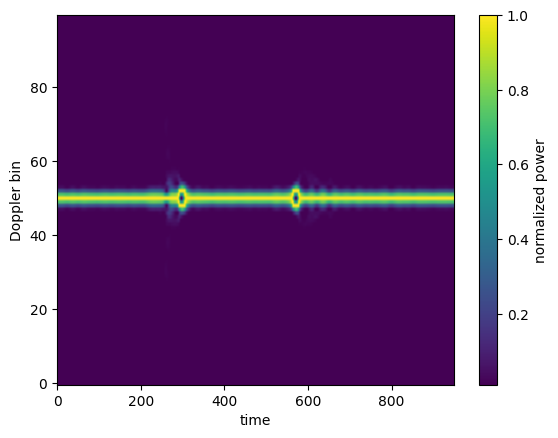

In [11]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from xrf55_dataset import XRF55DopplerDataset

train_dataset = XRF55DopplerDataset(
    cache_root=CACHE_ROOT,
    label_mode="action",
    scenes=SCENES,
    receivers=RECEIVERS,
    subjects=SUBJECTS,
    actions=ACTIONS,
    repetitions=TRAIN_REPETITIONS,
)
val_dataset = XRF55DopplerDataset(
    cache_root=CACHE_ROOT,
    label_mode="action",
    scenes=SCENES,
    receivers=RECEIVERS,
    subjects=SUBJECTS,
    actions=ACTIONS,
    repetitions=VAL_REPETITIONS,
)

print(f"train samples: {len(train_dataset)}")
print(f"val samples:   {len(val_dataset)}")
print(train_dataset.idx_to_label)

x, y = train_dataset[0]
print(f"sample shape: {tuple(x.shape)}")
print(f"label: {y.item()} -> {train_dataset.idx_to_label[y.item()]} {ACTION_NAMES.get(train_dataset.idx_to_label[y.item()], '')}")

plt.imshow(x[0].T, aspect="auto", origin="lower", cmap="viridis")
plt.xlabel("time")
plt.ylabel("Doppler bin")
plt.colorbar(label="normalized power")
plt.show()

# Training

In [ ]:
import copy

import torch
from torch import no_grad
from torch.cuda import is_available
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from tqdm.auto import tqdm
from IPython.display import clear_output

from models.base_model import SingleAntennaModel


def eval_single(model, dataloader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            batch_loss = loss_fn(logits, y)

            total_loss += batch_loss.item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    return {"loss": total_loss / total, "acc": correct / total}


EPOCHS = 25
BATCH_SIZE = 64
device = "cuda" if is_available() else "cpu"

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_dataset.label_to_idx)
model = SingleAntennaModel(num_classes=num_classes).to(device)

# Materialize LazyLinear before optimizer creation.
with no_grad():
    dummy = torch.zeros(1, *x.shape, device=device)
    _ = model(dummy)

print(sum(p.numel() for p in model.parameters()))

optimizer = Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    eps=1e-7,
    weight_decay=0.0,
)
loss = CrossEntropyLoss()

best_val_acc = 0.0
best_epoch = -1
best_state = None

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    total_steps = 0

    for x_batch, y_batch in tqdm(train_dataloader, leave=False):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        train_loss = loss(logits, y_batch)
        train_loss.backward()
        optimizer.step()

        running_loss += train_loss.item()
        total_steps += 1

    epoch_train_loss = running_loss / total_steps
    train_metrics = eval_single(model, train_dataloader, loss, device)
    val_metrics = eval_single(model, val_dataloader, loss, device)

    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_acc"].append(val_metrics["acc"])

    if val_metrics["acc"] > best_val_acc:
        best_val_acc = val_metrics["acc"]
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())

    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train loss")
    axes[0].plot(history["val_loss"], label="val loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history["train_acc"], label="train acc")
    axes[1].plot(history["val_acc"], label="val acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.show()

    print(
        f"epoch: {epoch + 1:03d}\n"
        f"  train_loss : {epoch_train_loss:.4f}\n"
        f"  train_acc  : {train_metrics['acc']:.4f}\n"
        f"  val_loss   : {val_metrics['loss']:.4f}\n"
        f"  val_acc    : {val_metrics['acc']:.4f}\n"
        f"  best_val   : {best_val_acc:.4f} @ epoch {best_epoch}"
    )

427636


  0%|          | 0/490 [00:00<?, ?it/s]

KeyboardInterrupt: 